# PINN Model Using Literature Data
This model uses **experimental data from Zhou (2025)**. 

# Imports

In [1204]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from scipy.stats import lognorm, weibull_min, genextreme, kstest
from dataclasses import dataclass
import random
import torch
import torch.nn as nn

# 1. Input Parameters
collects all inputs from experimental data and literature

## 1.1. Literature Data

In [1205]:
cleaned_sheets = pd.read_excel("/Users/jessiekreinsen/pinn-project/data/data_zhou_cleaned.xlsx", sheet_name=None)

with open("/Users/jessiekreinsen/pinn-project/data/data_zhou_metadata.json", "r") as f:
    metadata = json.load(f)

datasets = {}

for sheet_name, df in cleaned_sheets.items():
    datasets[sheet_name] = metadata[sheet_name]
    datasets[sheet_name]["data"] = df

*Data from* Zhou, S., Henrich, M., Wei, Z., Feng, F., Yang, B., & Münstermann, S. (2025). A general physics-informed neural network framework for fatigue life prediction of metallic materials. Engineering Fracture Mechanics, 322, 111136.

In [1206]:
# see available datasets
for name, info in datasets.items():
    print(name)
    print("  material:", info["material"])
    print("  category:", info["category"])
    print("  columns:", info["columns"])

Case 1 LZ50 steel
  material: LZ50 steel
  category: fatigue_life
  columns: ['stress_max', 'fatigue_life_cycles', 'log_life', 'temperature_k']
Case 2 SLM 316l
  material: SLM 316L
  category: fracture_mechanics
  columns: ['stress_max', 'deltaK', 'sqrt_A', 'l_leff', 'Nf']
Case 3 7075_T6_ratio
  material: Al7075-T6
  category: fatigue_life
  columns: ['stress_max', 'r-ratio', 'Nf']
Case 4 Al2024_T4
  material: Al2024
  category: stress_concentration
  columns: ['stress_max', 'r-ratio', 'Kt', 'Nf']
Case 4 Al7175_T7511
  material: Al7175
  category: stress_concentration
  columns: ['stress_max', 'r-ratio', 'Kt', 'Nf']
Case 4 Ti-4.5Al-3V-2Fe-2Mo
  material: Ti-4.5Al-3V-2Fe-2Mo
  category: stress_concentration
  columns: ['stress_max', 'r-ratio', 'Kt', 'Nf']
Case4 ZK60A-T5
  material: ZK60A-T5
  category: stress_concentration
  columns: ['stress_max', 'r-ratio', 'Kt', 'Nf']
Case 5 AMS 5707
  material: AMS 5707
  category: fatigue_life
  columns: ['stress_amp', 'Nf', 'r-ratio', 'temperature

### 1.1.a. Data Cleaning

In [1207]:
df_raw = datasets["Case 2 SLM 316l"]["data"].copy()

print("Raw Columns:", df_raw.columns.tolist())
print(df_raw.head())

Raw Columns: ['stress_max', 'deltaK', 'sqrt_A', 'l_leff', 'Nf']
   stress_max  deltaK  sqrt_A  l_leff      Nf
0         400    4.05      95    1.01  256343
1         400    4.54     117    1.00  197813
2         360    3.34      80    1.00  386505
3         360    4.29     132    1.00  325494
4         330    1.95      32    1.03  685035


In [1208]:
# confirm no missing values
print("\nMissing values:")
print(df_raw.isnull().sum())

print(f"\nShape: {df_raw.shape}")
print(df_raw.describe())


Missing values:
stress_max    0
deltaK        0
sqrt_A        0
l_leff        0
Nf            0
dtype: int64

Shape: (44, 5)
       stress_max     deltaK      sqrt_A     l_leff            Nf
count   44.000000  44.000000   44.000000  44.000000  4.400000e+01
mean   296.022727   3.359773  113.977273   1.029773  8.012786e+05
std     53.554792   0.751809   41.102531   0.059669  8.116100e+05
min    180.000000   1.840000   32.000000   0.920000  1.234240e+05
25%    270.000000   2.955000   86.500000   1.000000  3.119738e+05
50%    270.000000   3.335000  114.000000   1.015000  5.107765e+05
75%    330.000000   3.822500  132.000000   1.050000  8.686485e+05
max    400.000000   5.930000  282.000000   1.230000  3.296187e+06


In [1209]:
df = df_raw.copy()

print(df.columns.to_list())
print(df.head())

['stress_max', 'deltaK', 'sqrt_A', 'l_leff', 'Nf']
   stress_max  deltaK  sqrt_A  l_leff      Nf
0         400    4.05      95    1.01  256343
1         400    4.54     117    1.00  197813
2         360    3.34      80    1.00  386505
3         360    4.29     132    1.00  325494
4         330    1.95      32    1.03  685035


In [1210]:
# convert columns to numeric
df["stress_max"] = pd.to_numeric(df["stress_max"], errors="coerce")
df["deltaK"] = pd.to_numeric(df["deltaK"], errors="coerce")
df["sqrt_A"] = pd.to_numeric(df["sqrt_A"], errors="coerce")
df["l_leff"] = pd.to_numeric(df["l_leff"], errors="coerce")
df["Nf"] = pd.to_numeric(df["Nf"], errors="coerce")

### 1.1.b. Data Extraction

In [1211]:
# pull columns into numpy arrays for modeling
stress_max = df["stress_max"].to_numpy()
dKi = df["deltaK"].to_numpy()
sqrt_A = df["sqrt_A"].to_numpy()
l_leff = df["l_leff"].to_numpy()
Nf = df["Nf"].to_numpy()

# add column with converted √area, [micrometers] to area/crack size [m]
df["a0"] = (sqrt_A * 1e-6)**2           

# add column with geometry correction factor, Y
df["Y"] = np.where(np.isclose(df["l_leff"], 1.0, atol=0.05),
                   0.65, # surface
                   0.5)  # internal

# pull columns into numpy arrays for modeling
a0 = df["a0"].to_numpy()
Y = df["Y"].to_numpy()

In [1212]:
Nf_samples = df["Nf"].to_numpy(dtype=float)
sqrt_A_um = df["sqrt_A"].to_numpy(dtype=float)
dKi_samples = df["deltaK"].to_numpy(dtype=float)

sqrt_A_m = sqrt_A_um * 1e-6
a0 = sqrt_A_m**2

# clean valid positive values
sqrt_A_um = sqrt_A_um[np.isfinite(sqrt_A_um)]
sqrt_A_um = sqrt_A_um[sqrt_A_um > 0]

# convert to meters if desired
sqrt_A_m = sqrt_A_um * 1e-6

Defect complexity ratio ranges from 0.95 to 1.23 (Zhou et al. (2025)):
- L/Leff ≈ 1.0 → surface defect → Y = 0.65???
- L/Leff > 1.0 → internal defect → Y = 0.5

In [1213]:
# define a function to filter datasets by required columns
def get_datasets_with(required_cols):
    selected = {}

    for name, info in datasets.items():
        df = info["data"]

        if all(col in df.columns for col in required_cols):
            selected[name] = info

    return selected

defect_sets = get_datasets_with(["stress_max", "defect_size_m", "Nf"])

for name, info in defect_sets.items():
    print(name, info["material"])

Case 8 Al-Mg4.5-Mn Al-Mg4.5-Mn
Case Ti-6.5Al-2Zr-Mo-V Ti-6.5Al-2Zr-Mo-V


## 1.2. Material Parameters
Paris law constants, fracture toughness, threshold SIF

Paris–Erdogan law:  **da/dN = C · ΔK^m**
- valid for  K_th < ΔK < K_c  (Stage II crack growth)

In [1214]:
C = 0.76899e-7     # Paris constant [m/cycle / (MPa√m)^m]
m = 2.56492        # Paris exponent

print(f"Paris law: da/dN = {C:.2e} * deltaK^{m}")

Paris law: da/dN = 7.69e-08 * deltaK^2.56492


**UPDATE**
*For Paris constants, C and m:*
Wang, H. et al. (2022). Fatigue performance at ultra-low porosity of Ti6Al4V produced by laser powder bed fusion after post heat treatment. SSRN Electronic Journal, 2022. <https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4224194>.

## 1.3. Geometry Parameters
specimen dimensions, defect location (→ Y factor)

In [1215]:
# specimen dimensions: assume cylinderical gauge section, A = π * (d/2)^2
h = 10e-3               # height [m]
d = 5e-3                # diameter [m]
A = np.pi * (d/2)**2    # cross-sectional area [m^2]

V_gauge = A * h                # gauge volume [m^3]
V_gauge_mm3 = V_gauge * 1e9    # [mm^3] for display

print(f"Gauge volume V = {V_gauge_mm3:.1f} mm^3")

Gauge volume V = 196.3 mm^3


## 1.4. Loading Parameters
stress amplitude, mean stress, frequency

In [1216]:
stress_max = df["stress_max"]             # max stress [MPa]
stress_min = 0.0                          # assumed min stress [MPa]
stress_a = (stress_max - stress_min) / 2    # stress amplitude [MPa]

# R = stress_min / stress_max if stress_max != 0 else float("nan")

# Effective stress range:
    # crack faces close under compression, no damage contribution
delta_sigma = stress_max - stress_min

## 1.5. Process Params & VED
laser power, scan speed, hatch spacing, layer thickness

The Volumetric Energy Density (VED) is the laser energy input per unit volume of material:

**VED = P / (vht)**

where
- power, P, [W] = [J/s]
- scan velocity, v, [mm/s]
- layer thickness, t, [mm]
- hatch spacing, h, [mm]

and
- low VED → lack-of-fusion porosity
- high VED → keyhole porosity
- both increase defect density

Here, VED is a **process input** that controls defect statistics.

In [1217]:
# define process parameters
P = 280.0     # laser power [W]
v = 1200.0    # scan speed [mm/s]
h = 0.140     # hatch spacing [mm]
t = 0.03      # layer thickness [mm]

# volumetric energy density
VED_op = P / (v * h * t)

print(f"P = {P} W,  v = {v} mm/s,  h = {h} mm,  t = {t} mm")
print(f"VED_op = {VED_op:.2f} J/mm^3")

P = 280.0 W,  v = 1200.0 mm/s,  h = 0.14 mm,  t = 0.03 mm
VED_op = 55.56 J/mm^3


*For energy densities and parameters:*
Sola, A., Nouri, A., Peyre, P., Ghodbane, J., Sanz, C., Morville, S., Hueso, J., & Aubry, P. (2021). Processability of pure copper by laser powder bed fusion and its potential applications. Additive Manufacturing, 47, 102340. <https://www.sciencedirect.com/science/article/pii/S2214860420309246#tbl0005>. 

*More data:*
van der Linde, C., Sideris, I., Deillon, L., Afrasiabi, M., & Bambach, M. (2026). Microstructure engineering of Ti-6Al-4V in laser powder bed fusion via 1D thermal modeling and supporting experiments. arXiv:2604.24669.
https://arxiv.org/html/2604.24669v1 

# 2. Volume, Relative Density, and PDF
Process parameters determine the volumetric energy density (VED), which influences defect formation. Defect populations then determine the size of the largest critical defect in each specimen. Through fracture mechanics and the Paris law, the critical defect size controls the fatigue life.

This section will present the following:
- Volumetric Energy Density (VED) from AM process parameters
- Relative density from XCT data
- Expected defect count in the gauge volume
- Parametric PDF fit to measured defect sizes

## 2.1. VED & Densities

## 2.1. VED
A **simplified empirical approximation** curve relates VED to relative density. This relationship should be treated as illustrative.

*For relative densities and optimal VED values:*
Bittner, F., Müller, B., & Thielsch, J. (2022). Efficient LPBF-process development by Design of Experiments. Fraunhofer Institute for Machine Tools and Forming Technology (IWU), Dresden, Germany. <https://publica-rest.fraunhofer.de/server/api/core/bitstreams/5db78b1a-ed75-4d57-aa78-b5712aae8a45/content>. 

*For relative density values and expected relative density vs. VED curve:*
Park, H. et al. (2024). Relationship between volumetric energy density and relative density in laser powder bed fusion additive manufacturing: A review and analysis. Journal of Powder Materials, 2024. <https://www.powdermat.org/journal/view.php?doi=10.4150/jpm.2024.00038>.

In [1218]:
# define VED-relative density relationship parameters
VED_opt = 81.0        # optimal VED

rd_min = 0.865        # min relative density (normalized to 1 at optimal VED)
rd_max = 0.99992      # max relative density (normalized to 1 at optimal VED)

k = 0.05              # steepness of VED curve

## 2.2. Defect Size Distribution Parameters
Connect process parameters (VED) to defect-size population with **empirical statistical models**.

Assume defect size follows a **lognormal distribution** because defect growth results from *multiple multiplicative manufacturing effects* such as powder size variation, melt-pool instability, lack-of-fusion events, and gas entrapment. The lognormal distribution is widely used in additive manufacturing defect characterization because it:
- guarantees positive defect sizes,
- reproduces the right-skewed distributions commonly observed in XCT measurements,
- naturally accommodates rare large defects,
- is straightforward to sample in Monte Carlo simulations.

First, the defect size distribution parameters—**mean, standard deviation**—are calculated from the VED.

In [1219]:
# define functions to calculate defect size distribution parameters from VED

# mean of ln(defect size)
def defect_mu(VED, VED_opt):
    mu_0 = np.log(50e-6)        # assume exp(mu_ln) = 50 micrometers at VED_opt
    beta = 2e-6                 # sensitivity to VED deviation  [ln(m) / (J/mm^3)^2]
    
    mu_ln = mu_0 + beta * (VED - VED_opt)**2
    return mu_ln

# std dev of ln(defect size) as a function of VED
def defect_sigma(VED, VED_opt):
    sigma_0 = 0.35              # minimum log-scatter at optimal VED
    gamma = 1e-5                # scatter sensitivity to VED deviation

    sigma_ln = sigma_0 + gamma * (VED - VED_opt)**2
    return sigma_ln

mu_ln = defect_mu(VED_op, VED_opt)         # mean of log, ~3-6
sigma_ln = defect_sigma(VED_op, VED_opt)   # std dev of log, ~0.2-1

print(f"Defect size lognormal parameters at VED = {VED_op:.1f} J/mm^3:")
print(f"  mu_ln = {mu_ln:.4f} → median defect = {np.exp(mu_ln)*1e6:.1f} micrometers")
print(f"  sigma_ln = {sigma_ln:.4f}")

Defect size lognormal parameters at VED = 55.6 J/mm^3:
  mu_ln = -9.9022 → median defect = 50.1 micrometers
  sigma_ln = 0.3565


## 2.3. Fit Parametric PDF
Three candidate distributions are fitted by MLE.

The best distribution is selected by the lowest Kolmogorov–Smirnov statistic.

In [1220]:
# define a function to fit a parametric distribution to the defect sizes by MLE
def fit_distribution(sizes, dist_name):
    # lognormal distribution
    if dist_name == "lognormal":
        s, loc, scale = lognorm.fit(sizes, floc=0)
        frozen = lognorm(s=s, loc=0, scale=scale)
        params = {"mu_ln": np.log(scale), "sigma_ln": s}

    # Weibull distribution (3-parameter, with loc fixed at 0)
    elif dist_name == "Weibull":
        k, loc, scale = weibull_min.fit(sizes, floc=0)
        frozen = weibull_min(c=k, loc=0, scale=scale)
        params = {"k": k, "lambda": scale}

    # Gumbel distribution (for maxima, with loc and scale)
    elif dist_name == "Gumbel":
        from scipy.stats import gumbel_r
        loc, scale = gumbel_r.fit(sizes)
        frozen = gumbel_r(loc=loc, scale=scale)
        params = {"loc": loc, "scale": scale}

    else:
        raise ValueError(f"Unknown distribution: {dist_name!r}")

    ks_stat, ks_p = kstest(sizes, frozen.cdf)
    return frozen, ks_stat, ks_p, params

# fit each candidate distribution
data = sqrt_A_um

candidates = ["lognormal", "Weibull", "Gumbel"]
fit_results = {}

In [1221]:
# print results in a table to compare goodness-of-fit
print(f"{'Distribution':<12}  {'KS statistic':>14}  {'p-value':>10}")
print("-" * 42)

for name in candidates:
    frozen, ks, p, params = fit_distribution(data, name)
    fit_results[name] = (frozen, ks, p, params)
    print(f"{name:<12}  {ks:>14.4f}  {p:>10.4f}")

best_name = min(fit_results, key=lambda n: fit_results[n][1])
best_frozen, best_ks, best_p, best_params = fit_results[best_name]
print(f"\nBest fit: {best_name} (KS = {best_ks:.4f}, p = {best_p:.4f})")

param_str = ", ".join(f"{k} = {v:.4g}" for k, v in best_params.items())
print(f"Parameters: {param_str}")

Distribution    KS statistic     p-value
------------------------------------------
lognormal             0.0938      0.7999
Weibull               0.1279      0.4322
Gumbel                0.0908      0.8296

Best fit: Gumbel (KS = 0.0908, p = 0.8296)
Parameters: loc = 95.94, scale = 33.23


### 2.3.a. Defect Size Histogram & PDF

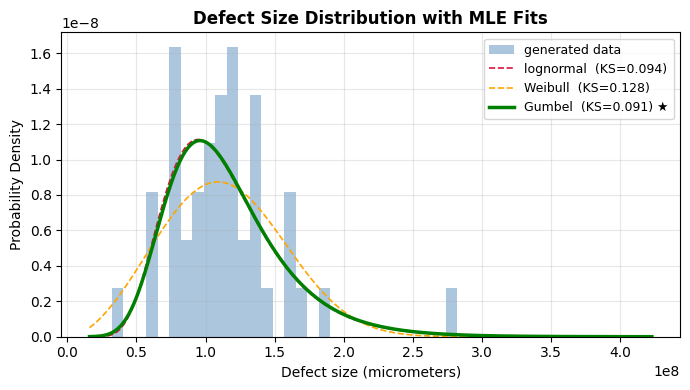

In [1222]:
# plot histogram of defect sizes and overlay fitted PDFs
fig, ax = plt.subplots(figsize=(7, 4))

sizes_um = data * 1e6   # convert to micrometers for readability
ax.hist(sizes_um, bins=30, density=True, alpha=0.45,
        color="steelblue", label="generated data")

# overlay all three fitted PDFs
colors = {"lognormal": "crimson", "Weibull": "orange", "Gumbel": "green"}
x_m = np.linspace(data.min() * 0.5, data.max() * 1.5, 500)
x_um = x_m * 1e6

for name, (frozen, ks, p, _) in fit_results.items():
    pdf_vals = frozen.pdf(x_m) / 1e6   # Jacobian: dx_m = dx_um / 1e6
    lw = 2.5 if name == best_name else 1.2
    ls = "-" if name == best_name else "--"
    ax.plot(x_um, pdf_vals, color=colors[name], linewidth=lw, linestyle=ls,
            label=f"{name}  (KS={ks:.3f})" + (" ★" if name == best_name else ""))

# axes labels, title
ax.set_title("Defect Size Distribution with MLE Fits", fontweight="bold")
ax.set_xlabel("Defect size (micrometers)")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs_pinn/2_defect_pdf.png", dpi=150)
plt.show()

## 2.4. Max.-Defect Distribution
The maximum defect is given in the data by √A.

### 2.4.a. Generalized Extreme Value Distribution (GEV)
- each specimen contains many defects
- fatigue failure is governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

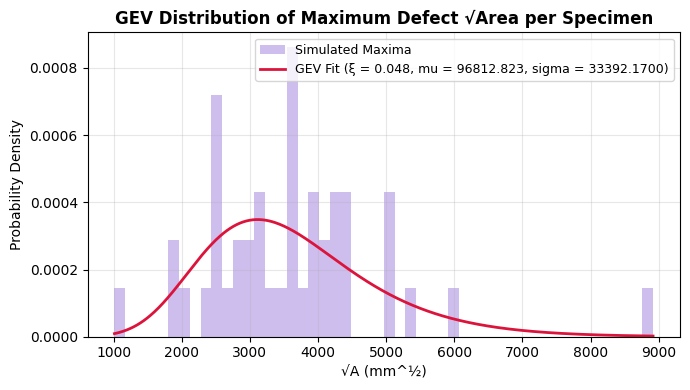

In [1248]:
# GEV fit to per-specimen maximum defect sizes
        # gev_c = shape parameter (ξ)
        # gev_loc = location parameter (mu)
        # gev_scale = scale parameter (sigma)
gev_c, gev_loc, gev_scale = genextreme.fit(sqrt_A_um)

x_gev = np.linspace(sqrt_A.min(), sqrt_A.max(), 500)
pdf_gev = genextreme.pdf(x_gev, gev_c, gev_loc, gev_scale)

# convert [sqrt(m)] to [sqrt(mm)]
conv = np.sqrt(1000)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(sqrt_A * conv,
        bins=50,
        density=True,
        alpha=0.45,
        color="mediumpurple",
        label="Simulated Maxima")

ax.plot(x_gev * conv,
        pdf_gev / conv,
        color="crimson",
        linewidth=2,
        label=f"GEV Fit (ξ = {gev_c:.3f}, mu = {gev_loc*1e3:.3f}, sigma = {gev_scale*1e3:.4f})")

# axes labels, title
ax.set_title("GEV Distribution of Maximum Defect √Area per Specimen", fontweight="bold")
ax.set_xlabel("√A (mm^½)")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs_pinn/2_GEV.png", dpi=150)
plt.show()

## 2.5. Paris-Law Fatigue Life Formulas
Integrating Paris law from a_0 to a_f with the Shiozawa approximation
(a_f >> a_i, so the a_f term → 0 for m > 2):

        N_f ≈ 2 / [(m-2) · C · (Y·delta_sigma)^m · pi^(m/2)] · a_i^(1 - m/2)

Re-written in terms of the initial SIF range deltaK_i = Y·delta_sigma·√(pi·a_i):

        N_f ≈ 2 / [(m-2) · C · pi · (Y·delta_sigma)^2] · deltaK_i^(2-m)

In [1224]:
# define function based on Paris law
def fatigue_life_paris(a_i, stress_a, C, m, Y, delta_sigma=None):

    # fully reversed (R = -1)
    if delta_sigma is None:
        delta_sigma = 2.0 * stress_a
    
    # constant of Paris/Shiozawa equation
    paris_coeff = 2.0 / ((m-2.0) * C * (Y * delta_sigma)**m * np.pi**(m/2))

    Nf = paris_coeff * a_i**(1.0-(m/2.0))
    return Nf

def fatigue_life_paris_torch(a0, stress_a, C, m, Y, delta_sigma=None):

    # fully reversed loading, R = -1
    if delta_sigma is None:
        delta_sigma = 2.0 * stress_a

    # constant of Paris/Shiozawa equation
    paris_coeff = 2.0 / ((m-2.0) * C * (Y * delta_sigma)**m * torch.pi**(m / 2.0))

    Nf = paris_coeff * a0**(1.0 - (m / 2.0))
    return Nf

The **stress intensity factor, delta(K)**, the measure of the severity of a crack situation, is determined by

**delta(K) = Y * stress_amp * sqrt(pi * A)**

Assume the defect_size is the crack length: defect_size, A = crack_length, a

In [1225]:
# define function to compute stress intensity factor, deltaK
def stress_intensity_factor(stress_amp, defect_size):
    deltaK = Y * stress_amp * np.sqrt(np.pi * defect_size)
    return deltaK

def stress_intensity_factor_torch(stress_amp, defect_size):
    deltaK = Y * stress_amp * torch.sqrt(torch.pi * defect_size)
    return deltaK

# define a function to compute the initial SIF range deltaK_i for a given initial crack size a_i
def delta_K_initial(a_i, delta_sigma, Y):
    deltaK_i = Y * delta_sigma * np.sqrt(np.pi * a_i)   # [MPa√m]
    return deltaK_i

## 2.6. Fatigue Life Dist. at Fixed Stress
Paris law & Shiozawa give N_f for each specimen.

The resulting distribution captures the scatter from defect variability alone.

In [1226]:
S_fixed = 500.0   # stress amplitude [MPa]

Nnorm_samples = Nf_samples / sqrt_A_m

# create one shared mask for valid rows (positive finite fatigue lives)
valid_mc = (
    np.isfinite(a0) &
    np.isfinite(Nf_samples) & (Nf_samples > 0) &
    np.isfinite(dKi_samples) & (dKi_samples > 0) &
    np.isfinite(Nnorm_samples) & (Nnorm_samples > 0)
)

# apply the same mask to everything
a0_valid = a0[valid_mc]
Nf_samples_valid = Nf_samples[valid_mc]
dKi_samples_valid = dKi_samples[valid_mc]
Nnorm_samples_valid = Nnorm_samples[valid_mc]

### 2.6.a Shiozawa Plot: deltaK_i vs N_f / √A
Expected slope from Paris law:
(N/√A) ∝ (deltaK_i)^(-m)
log(deltaK_i) = -(1/m)*log(N/√A) + C
→ **slope = -1/m**

In [1227]:
# log-log linear fit
log_Nnorm = np.log10(Nnorm_samples_valid).flatten()
log_dKi = np.log10(dKi_samples_valid).flatten()

In [1228]:
# fit line
slope, intercept = np.polyfit(log_Nnorm, log_dKi, 1)
a_fit = 10**intercept

# compare slope to expected from Paris law
expected_slope = -1.0 / m

print(f"Shiozawa log-log fit: slope = {slope:.4f}")
print(f"Expected from Paris (m={m}): slope = {expected_slope:.4f}")

# convert to numpy arrays
Nnorm_samples = np.asarray(Nnorm_samples, dtype=float)

N_norm_line = np.logspace(
    np.log10(Nnorm_samples.min()),
    np.log10(Nnorm_samples.max()),
    300
)
dK_line = a_fit * N_norm_line**slope

Shiozawa log-log fit: slope = -0.1885
Expected from Paris (m=2.56492): slope = -0.3899


In [1229]:
# confidence intervals for the fit line

# create bins for logNnorm
bins_Nnorm = np.linspace(min(log_Nnorm), max(log_Nnorm), 20)

# calculate mean and std dev of stress values in each bin
log_dKi_avg = []
log_dKi_std = []
centers = []

for i in range(len(bins_Nnorm) - 1):
    mask = (log_Nnorm >= bins_Nnorm[i]) & (log_Nnorm < bins_Nnorm[i+1])
    Ks_in_bin = np.array(log_dKi)[mask]

    if Ks_in_bin.size == 0:
        continue
    
    log_dKi_avg.append(np.mean(Ks_in_bin))
    log_dKi_std.append(np.std(Ks_in_bin))
    centers.append(0.5 * (bins_Nnorm[i] + bins_Nnorm[i+1]))

log_dKi_avg = np.array(log_dKi_avg)
log_dKi_std = np.array(log_dKi_std)
centers = np.array(centers)

# confidence intervals, assume 96% CI
upper_K = log_dKi_avg + 1.96 * log_dKi_std
lower_K = log_dKi_avg - 1.96 * log_dKi_std

# convert log-space CI back to real ΔK values
upper_dK = 10**upper_K
lower_dK = 10**lower_K
xvals1 = 10**centers

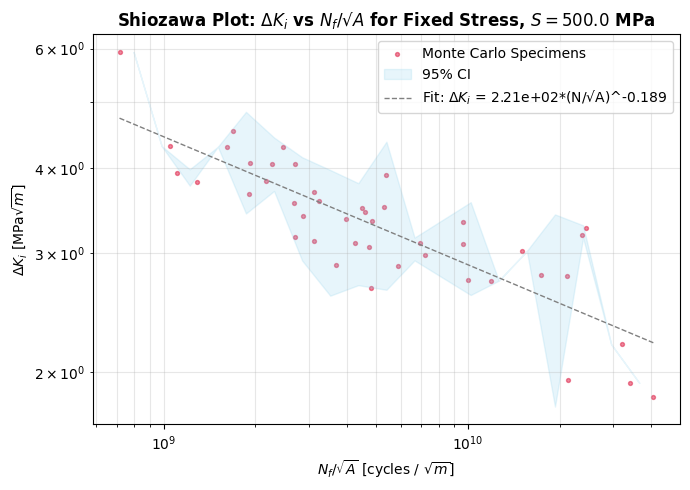

In [1230]:
# plot Shiozawa plot
fig, ax = plt.subplots(figsize=(7, 5))

# show Monte Carlo specimens as scatter points
ax.scatter(Nnorm_samples, dKi_samples, alpha=0.5, s=8, color="crimson",
           label="Monte Carlo Specimens")

# show confidence intervals as shaded area
plt.fill_between(xvals1, lower_dK, upper_dK,
                 color='skyblue',
                 alpha=0.2,
                 label='95% CI')

# show fitted line from log-log fit
ax.plot(N_norm_line, dK_line, color="grey", linewidth=1, linestyle="--",
        label=f"Fit: $\\Delta K_i$ = {a_fit:.2e}*(N/√A)^{slope:.3f}")

# log-log scale for Shiozawa plot
ax.set_xscale("log")
ax.set_yscale("log")

# axes labels, title
ax.set_title(f"Shiozawa Plot: $\\Delta K_i$ vs $N_f / √A$ for Fixed Stress, $S = {S_fixed}$ MPa",
             fontweight="bold")
ax.set_xlabel("$N_f / \\sqrt{A}$ [cycles / $\\sqrt{m}$]")
ax.set_ylabel("$\\Delta K_i$ [MPa$\\sqrt{m}$]")

# legend, grid
ax.legend()
ax.grid(alpha=0.3, which="both")

# save and show
plt.tight_layout()
plt.savefig("graphs_pinn/2_shiozawa.png", dpi=150)
plt.show()

### 2.6.b Reliability Curves: Empirical & Weibull Model

The fraction of specimens surviving beyond N cycles:

**R(N) = P(N_f > N)**

The Weibull model **R(N) = exp[-(N/η)^β]** is fitted for comparison

where:

- R(N) = reliability
- η = characteristic life
- β = Weibull shape parameter

Weibull: β = 1.139, η = 8.453e+05
  B10 (10% failure) = 1.172e+05 cycles
  B50 (50% failure) = 6.128e+05 cycles


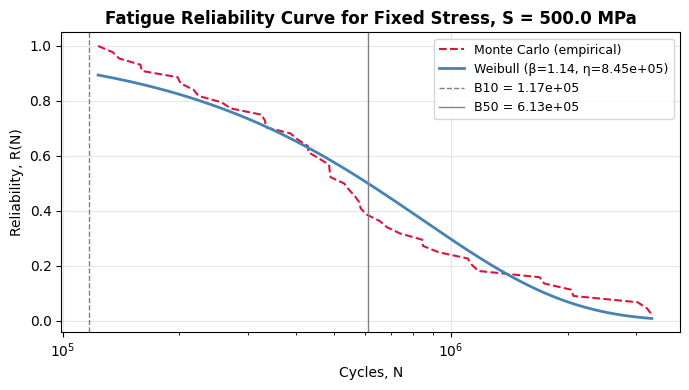

In [1231]:
lives_sorted = np.sort(Nf_samples_valid)
R_empirical  = 1.0 - np.arange(len(lives_sorted)) / len(lives_sorted)

# Weibull MLE fit
shape_w, _, scale_w = weibull_min.fit(Nf_samples, floc=0)
N_vals = np.linspace(lives_sorted.min(), lives_sorted.max(), 500)
R_weibull = np.exp(-(N_vals / scale_w)**shape_w)

# B10 and B50 lives
B10 = scale_w * (-np.log(0.90))**(1.0 / shape_w)        # 10% failure → R = 0.90
B50 = scale_w * (-np.log(0.50))**(1.0 / shape_w)        # 50% failure → R = 0.50
print(f"Weibull: β = {shape_w:.3f}, η = {scale_w:.3e}")
print(f"  B10 (10% failure) = {B10:.3e} cycles")
print(f"  B50 (50% failure) = {B50:.3e} cycles")

# plot reliability curves
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lives_sorted, R_empirical, color="crimson", linewidth=1.5,
        linestyle="--", label="Monte Carlo (empirical)")
ax.plot(N_vals, R_weibull, color="steelblue", linewidth=2,
        label=f"Weibull (β={shape_w:.2f}, η={scale_w:.2e})")
# show B10 and B50 as vertical lines
ax.axvline(B10, color="grey", linewidth=1, linestyle="--",
           label=f"B10 = {B10:.2e}")
ax.axvline(B50, color="grey", linewidth=1,
           label=f"B50 = {B50:.2e}")

# log scale for reliability plot
ax.set_xscale("log")

# axes labels, title
ax.set_title(f"Fatigue Reliability Curve for Fixed Stress, S = {S_fixed} MPa",
             fontweight="bold")
ax.set_xlabel("Cycles, N")
ax.set_ylabel("Reliability, R(N)")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs_pinn/2_reliability.png", dpi=150)
plt.show()

## 2.7. Shiozawa Curves for Varying Stress Amps.

Each stress level produces a shifted band on the **deltaK_i vs N_f/√A** plot.

With Paris law physics, these bands should **collapse onto a single trendline** when the Murakami normalization is applied, thus confirming the consistency of the framework.

Shiozawa collapse fit: slope = -0.4172
Expected from Paris (m=2.56492): slope = -0.3899


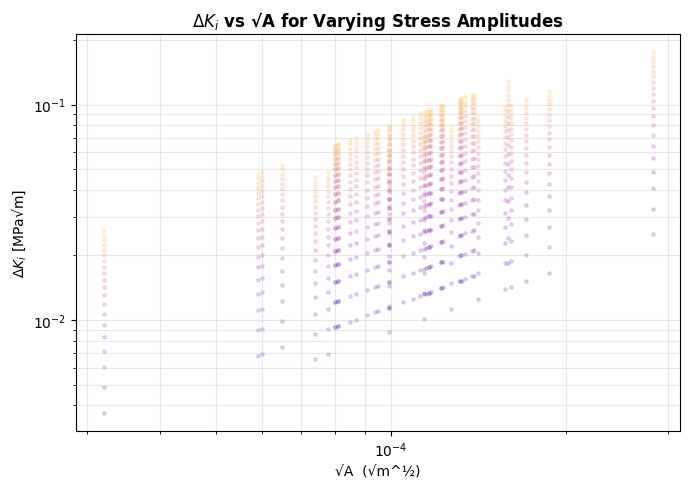

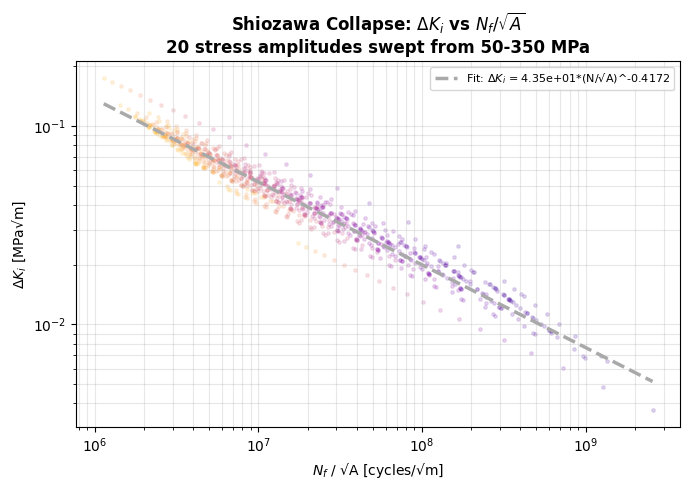

In [1232]:
S_vals = np.linspace(50, 350, 20)     # stress amplitudes to sweep [MPa]

# empty lists to store info
dKi_all = []
Nnorm_all = []

# create subplots for deltaK_i vs √A and deltaK_i vs N/√A
fig1, ax1 = plt.subplots(figsize=(7, 5))    # deltaK_i vs √A
fig2, ax2 = plt.subplots(figsize=(7, 5))    # deltaK_i vs N/√A  (Shiozawa collapse)

colors_s = plt.cm.plasma(np.linspace(0.1, 0.85, len(S_vals)))

for Si, ci in zip(S_vals, colors_s):
    ds_i = 2.0 * Si                       # delta_sigma for R = -1
    
    Nf_i = fatigue_life_paris(a0, Si, C, m, Y, delta_sigma=ds_i)
    dKi_i = delta_K_initial(a0, ds_i, Y)
    sqrt_A_i = np.sqrt(a0)

    Nnorm_i = (Nf_i / sqrt_A_i)           # normalized life, N/√A [cycles/√m]
    
    # store results
    dKi_all.append(dKi_i)
    Nnorm_all.append(Nnorm_i)

    # plots
    ax1.scatter(sqrt_A_i, dKi_i, alpha=0.15, s=6, color=ci,
                #label=f"S = {Si} MPa"
                )
    ax2.scatter(Nnorm_i, dKi_i, alpha=0.15, s=6, color=ci,
                #label=f"S = {Si} MPa"
                )

all_dKi = np.concatenate(dKi_all) 
all_Nnorm = np.concatenate(Nnorm_all)

log_x = np.log10(all_Nnorm)
log_y = np.log10(all_dKi)

slope, intercept = np.polyfit(log_x, log_y, 1)

x_line = np.logspace(log_x.min(), log_x.max(), 300)
y_line = 10**intercept * x_line**slope

print(f"Shiozawa collapse fit: slope = {slope:.4f}")
print(f"Expected from Paris (m={m}): slope = {expected_slope:.4f}")

# show fitted line from log-log fit on shiozawa collapse plot
ax2.plot(x_line, y_line, color="darkgray", linewidth=2.5, linestyle="--",
         label=f"Fit: $\\Delta K_i$ = {10**intercept:.2e}*(N/√A)^{slope:.4f}")

for ax, xlabel, title in [
    # x-axis label, title for each plot
    (ax1, "√A  (√m^½)",
     "$\\Delta K_i$ vs √A for Varying Stress Amplitudes"),
    (ax2, "$N_f$ / √A [cycles/√m]",
     "Shiozawa Collapse: $\\Delta K_i$ vs $N_f/\\sqrt{A}$\n"
     "20 stress amplitudes swept from 50-350 MPa"),
]:

    # log-log scale for both plots
    ax.set_xscale("log")
    ax.set_yscale("log")

    # axes labels, titles for both plots
    ax.set_xlabel(xlabel)
    ax.set_ylabel("$\\Delta K_i$ [MPa√m]")
    ax.set_title(title, fontweight="bold")
    
    # legends, grids
    ax.grid(alpha=0.3, which="both")

ax2.legend(fontsize=8, ncol=2, #title="Stress Amplitude"
           )
# save and show
fig1.tight_layout(); fig1.savefig("graphs_pinn/2_shiozawa_dK_sqrtA.png", dpi=150)
fig2.tight_layout(); fig2.savefig("graphs_pinn/2_shiozawa_collapse.png",  dpi=150)
plt.show()

Across a dense sweep of stress amplitudes, the Shiozawa collapse is visible.

## 2.8. PSN Curves
probability S-N curves

In [1233]:
S_vals = np.linspace(50, 350, 20)     # stress amplitudes to sweep [MPa]

# probabilities of failure
pf_levels = [0.10, 0.50, 0.90]   # B10, B50, B90
labels = ["B10", "B50", "B90"]

psn_results = {label: [] for label in labels}

for S in S_vals:
    ds = 2.0 * S   # for R = -1

    # fatigue lives for all sampled max defects at this stress
    Nf_S = fatigue_life_paris(a0, S, C, m, Y, delta_sigma=ds)
    Nf_S = np.asarray(Nf_S, dtype=float)

    # remove invalid values if needed
    Nf_S = Nf_S[np.isfinite(Nf_S)]
    Nf_S = Nf_S[Nf_S > 0]

    # percentile lives
    for pf, label in zip(pf_levels, labels):
        psn_results[label].append(np.quantile(Nf_S, pf))

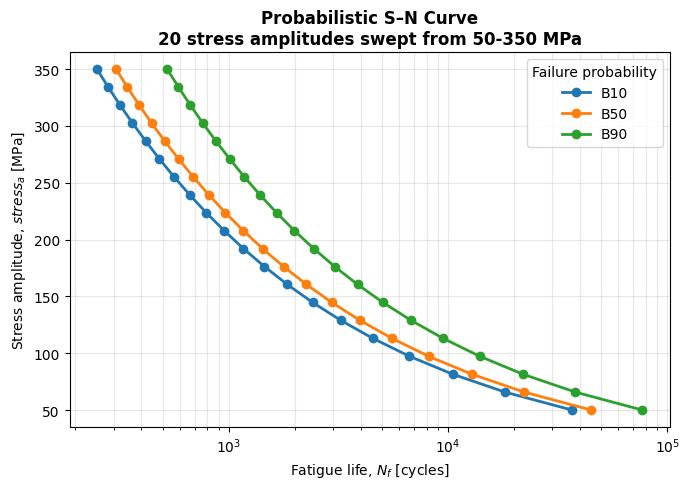

In [1234]:
fig, ax = plt.subplots(figsize=(7, 5))

for label in labels:
    ax.plot(psn_results[label], S_vals,
        marker="o", linewidth=2, label=label
    )

# log scale for fatigue life
ax.set_xscale("log")

# axes labels, title, legend, grid
ax.set_xlabel(r"Fatigue life, $N_f$ [cycles]")
ax.set_ylabel(r"Stress amplitude, $stress_a$ [MPa]")
ax.set_title("Probabilistic S–N Curve\n"
             "20 stress amplitudes swept from 50-350 MPa", fontweight="bold")

# legend, grid
ax.grid(True, which="both", alpha=0.3)
ax.legend(title="Failure probability")

# save and show
fig.tight_layout()
fig.savefig("graphs_pinn/2_psn.png", dpi=150)
plt.show()

# 3. PINN

In [1235]:
# reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [1236]:
# convert data to tensors
a_tensor = torch.tensor(a0_valid, dtype=torch.float32).unsqueeze(1)           # input = max defect / initial crack size
Nf_tensor = torch.tensor(Nf_samples_valid, dtype=torch.float32).unsqueeze(1)  # output = fatigue life
Y_valid = torch.tensor(Y[valid_mc], dtype=torch.float32).unsqueeze(1)
stress_max_valid = torch.tensor(df["stress_max"].to_numpy(dtype=float)[valid_mc],
                                dtype=torch.float32).unsqueeze(1)
delta_sigma_valid = stress_max_valid   # since stress_min = 0
stress_a_valid = delta_sigma_valid / 2

# log-transform input and output for better scaling
log_a = torch.log(a_tensor)
log_Nf = torch.log(Nf_tensor)

# normalize input defect sizes
log_a_mean = log_a.mean()
log_a_std = log_a.std()
a_scaled = (log_a - log_a_mean) / log_a_std

# normalize output cycles
log_Nf_mean = log_Nf.mean()
log_Nf_std = log_Nf.std()
N_scaled = (log_Nf - log_Nf_mean) / log_Nf_std

## 3.1. Define PINN

In [1237]:
# # define data
# X = [a0, stress_max, Y]
# y = Nf

In [1238]:
# define custom NN class
# lets PyTorch track parameters and gradients automatically
class PINN(nn.Module):
    def __init__(self): # initializes nn.Module
        super().__init__()
        self.net = nn.Sequential( # sequential container for layers, = feed-forward pipeline
            
            # first hidden layer
            nn.Linear(1, 64), # (input, output)
            # nn.Linear(3, 64), # if (input=3 variables)
            nn.Tanh(),
            
            # second hidden layer
            nn.Linear(64, 64),
            nn.Tanh(),

            # output = 1 number (N), since we want to predict a single fatigue life value for each input N/√A
            nn.Linear(64, 1) 
        )

    # forward method defines how input data flows through the network
    def forward(self, N):
        log_Nf_scaled = self.net(N) # predicts scaled log(Nf)

        # convert back to physical fatigue life
        log_Nf = log_Nf_scaled * log_Nf_std + log_Nf_mean
        Nf = torch.exp(log_Nf)        # makes prediction physical and positive
        
        # predicts Nf(N)
        return Nf 

PINN Architecture from Liao et al. (2025):
- 2 hidden layers 
- 64 neurons each 
- Tanh activation function

Liao et al. (2025). A physics-informed neural network method for identifying parameters and predicting remaining life of fatigue crack growth International. Journal of Fatigue, 191, 108678. https://doi.org/10.1016/j.ijfatigue.2024.108678.

## 3.2. Define Losses

### 3.2.a. Physics Loss: Paris Law

In [1239]:
# define a function to enforce the Paris Law
# everything in physics_loss must be torch operations to allow autograd to compute gradients
def physics_loss(model, a_scaled, a_physical, stress_a, C, m, Y, delta_sigma):
    Nf_pred = model(a_scaled)

    Nf_physics = fatigue_life_paris_torch(a_physical, stress_a, C, m, Y, delta_sigma)

    return torch.mean((Nf_pred - Nf_physics)**2)    # MSE loss

### 3.2.b. Data Loss

In [1240]:
# define a function to compute the data loss
# log-MSE between predicted and true defect sizes
def data_loss_logMSE(model, a_scaled, Nf_true):
    Nf_pred = model(a_scaled)
    return torch.mean((torch.log(Nf_pred) - torch.log(Nf_true))**2)

# MSE between predicted and true defect sizes
def data_loss_MSE(model, a_scaled, Nf_true):
    Nf_pred = model(a_scaled)
    return torch.mean((Nf_pred - Nf_true)**2)

Liao et al. (2025) uses 𝐿𝑜𝑠𝑠_𝐷 = 𝑀𝑆𝐸(𝑛_𝑝𝑟𝑒𝑑, 𝑛_𝑜𝑏𝑠) as the data loss function.

## 3.3. Training

In [1241]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 5000

loss_history = []
physics_loss_history = []
data_loss_history = []

# weights
w_d_liao = 100.0    # weight for data loss, from Liao et al. (2025)
w_p_liao = 1.0      # weight for physics loss, from Liao et al. (2025)
w_d = 0.9           # weight for data loss
w_p = 0.1           # weight for physics loss

# train for many iterations (epochs)
for epoch in range(epochs):
    optimizer.zero_grad()       # reset gradients before backprop

    # define losses
    loss_d = data_loss_MSE(model, a_scaled, Nf_tensor)               # enforces fit to data
    loss_p = physics_loss(model, a_scaled, a_tensor, stress_a_valid, C, m, Y_valid, delta_sigma_valid)    # enforces diff eqn everywhere

    # weighted total loss
    loss = w_d_liao * loss_d + w_p_liao * loss_p

    loss.backward()             # backpropagation: computes gradients of all parameters
    optimizer.step()            # updates network weights

    loss_history.append(loss.item())
    physics_loss_history.append(loss_p.item())
    data_loss_history.append(loss_d.item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total: {loss.item():.4e} | "
            f"Data: {loss_d.item():.4e} | "
            f"Physics: {loss_p.item():.4e} | "
        )

Epoch     0 | Total: 6.8069e+13 | Data: 6.7736e+11 | Physics: 3.3325e+11 | 
Epoch   500 | Total: 5.2523e+13 | Data: 5.1776e+11 | Physics: 7.4695e+11 | 
Epoch  1000 | Total: 2.9618e+13 | Data: 2.8647e+11 | Physics: 9.7147e+11 | 
Epoch  1500 | Total: 2.3664e+13 | Data: 2.2631e+11 | Physics: 1.0330e+12 | 
Epoch  2000 | Total: 1.6988e+13 | Data: 1.5868e+11 | Physics: 1.1203e+12 | 
Epoch  2500 | Total: 1.5320e+13 | Data: 1.4206e+11 | Physics: 1.1142e+12 | 
Epoch  3000 | Total: 1.4890e+13 | Data: 1.3771e+11 | Physics: 1.1187e+12 | 
Epoch  3500 | Total: 1.4756e+13 | Data: 1.3636e+11 | Physics: 1.1202e+12 | 
Epoch  4000 | Total: 1.4695e+13 | Data: 1.3575e+11 | Physics: 1.1204e+12 | 
Epoch  4500 | Total: 1.4648e+13 | Data: 1.3527e+11 | Physics: 1.1211e+12 | 


*For weights (lambda_d = 100, lambda_p = 1), of first implementation*: Liao et al. (2025).

## 3.4. Predictions

In [1242]:
model.eval()

with torch.no_grad():
    Nf_pred = model(a_scaled).numpy()

a_np = a_tensor.numpy()
Nf_true_np = Nf_tensor.numpy()
Nf_pred_np = Nf_pred

# sort for plotting
sort_idx = np.argsort(a_np)
a_sorted = a_np[sort_idx]
Nf_true_sorted = Nf_true_np[sort_idx]
Nf_pred_sorted = Nf_pred_np[sort_idx]

### 3.4.a. Evaluation

In [1243]:
# prediction errors
errors = Nf_pred_np - Nf_true_np

mse = np.mean(errors**2)        # mean squared error
rmse = np.sqrt(mse)             # root mean squared error
mae = np.mean(np.abs(errors))   # mean absolute error

# log-space errors
log_errors = np.log(Nf_pred_np) - np.log(Nf_true_np)

log_mse  = np.mean(log_errors**2)
log_rmse = np.sqrt(log_mse)
log_mae  = np.mean(np.abs(log_errors))

# print results table
print(f"{'Metric':<10} {'Value':>14} {'Log Value':>14}")
print("-" * 42)

print(f"{'MSE':<10} {mse:>14.4e} {log_mse:>14.4e}")
print(f"{'RMSE':<10} {rmse:>14.4e} {log_rmse:>14.4e}")
print(f"{'MAE':<10} {mae:>14.4e} {log_mae:>14.4e}")

Metric              Value      Log Value
------------------------------------------
MSE            1.3485e+11     1.6446e-01
RMSE           3.6723e+05     4.0554e-01
MAE            1.8477e+05     2.6586e-01


### 3.4.b. Accuracy Plots

#### 3.4.b.i Training History Plots

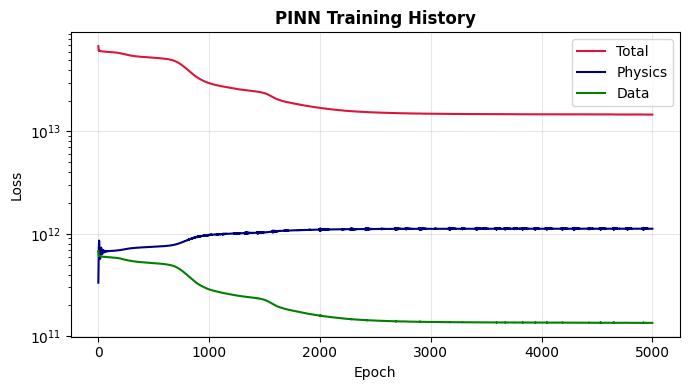

In [1244]:
# plot training history
fig, ax = plt.subplots(figsize=(7,4))

ax.plot(loss_history, color="crimson", label="Total")
ax.plot(physics_loss_history, color="navy", label="Physics")
ax.plot(data_loss_history, color="green", label="Data")
#ax.plot(boundary_loss_history, color="red", label="Boundary")

# log scale
ax.set_yscale("log")

# axes labels, title
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("PINN Training History", fontweight="bold")

# legend, grid
ax.grid(alpha=0.3)
ax.legend()

# save and show
plt.tight_layout()
plt.savefig("graphs_pinn/3_PINN_loss_history.png", dpi=150)
plt.show()

Observations from **PINN Training History** plot after the **first implementation** with weights from Liao et al. (2025):

- **Data loss** is decreasing smoothly over training. So, the network is fitting the training data better and better.

- **No instability**: oscillations, no exploding gradients, no null values--good news!

- **Physics loss** is basically constant. It should be decreasing. Therefore, the optimizer is prioritizing the data loss over the physics loss.
--> The weights, lambda_d = 100, lambda_p = 1, are greatly uneven.

#### 3.4.c.ii Predicted vs. True Defect Sizes

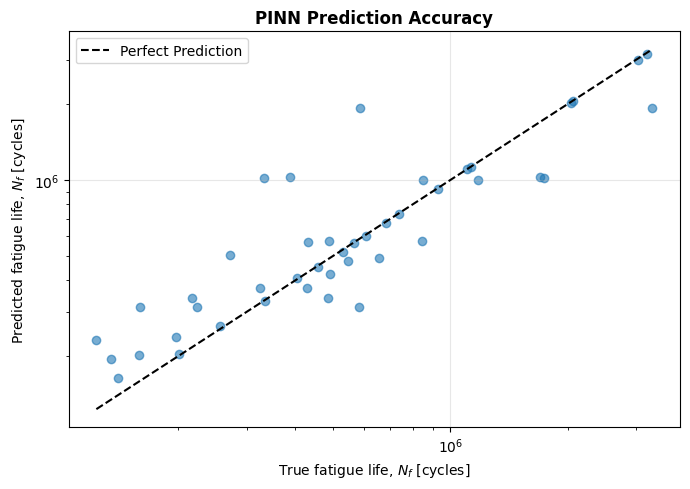

In [1245]:
# plot predicted vs. true defect sizes
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(Nf_true_np, Nf_pred_np, alpha=0.6)

min_val = min(Nf_true_np.min(), Nf_pred_np.min())
max_val = max(Nf_true_np.max(), Nf_pred_np.max())

ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black", label="Perfect Prediction")

# log-log scale
ax.set_xscale("log")
ax.set_yscale("log")

# axes labels, title
ax.set_xlabel(r"True fatigue life, $N_f$ [cycles]")
ax.set_ylabel(r"Predicted fatigue life, $N_f$ [cycles]")
ax.set_title("PINN Prediction Accuracy", fontweight="bold")

# legend, grid
ax.grid(alpha=0.3)
ax.legend()

# save and show
fig.tight_layout()
fig.savefig("graphs_pinn/3_PINN_accuracy_pred_vs_true.png", dpi=150)
plt.show()

The flattening at large crack sizes suggests the network is underpredicting the largest defects.

### 3.4.b. Crack Growth Curve

In [1246]:
# fix shapes for plotting
a_np = a_tensor.detach().cpu().numpy().squeeze()
Nf_true_np = Nf_tensor.detach().cpu().numpy().squeeze()
Nf_pred_np = Nf_pred.squeeze()

sort_idx = np.argsort(a_np)

a_sorted = a_np[sort_idx]
Nf_true_sorted = Nf_true_np[sort_idx]
Nf_pred_sorted = Nf_pred_np[sort_idx]

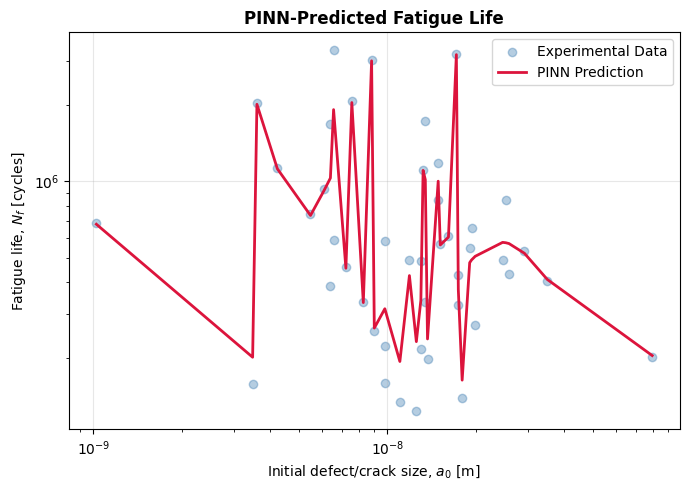

In [1247]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(a_sorted, Nf_true_sorted, color="steelblue", alpha=0.4, label="Experimental Data")
ax.plot(a_sorted, Nf_pred_sorted, color="crimson", linewidth=2, label="PINN Prediction")

# log-log scale
ax.set_xscale("log")
ax.set_yscale("log")

# labels, title
ax.set_xlabel(r"Initial defect/crack size, $a_0$ [m]")
ax.set_ylabel(r"Fatigue life, $N_f$ [cycles]")
ax.set_title("PINN-Predicted Fatigue Life", fontweight="bold")

# legend, grid
ax.grid(alpha=0.3)
ax.legend()

# save and show
fig.tight_layout()
fig.savefig("graphs_pinn/3_PINN_life_vs_defect.png", dpi=150)
plt.show()